In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd
 # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/products.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/sample_submission.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/promotions.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/shipments.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/order_items.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/reviews.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/inventory.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/returns.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/sales.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/orders.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/geography.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/customers.csv
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/baseline.ipynb
/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/payments.csv
/kaggle/input/datasets/uynttrnnh/da

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [4]:
# Đọc dữ liệu từ file csv
customers = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/customers.csv")
geography = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/geography.csv")
inventory = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/inventory.csv")
order_items = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/order_items.csv")
orders = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/orders.csv")
payments = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/payments.csv")
products = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/products.csv")
promotions = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/promotions.csv")
returns = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/returns.csv")
reviews = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/reviews.csv")
sales = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/sales.csv")
shipments = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/shipments.csv")
web_traffic = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/web_traffic.csv")

/tmp/ipykernel_57/1316847536.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("/kaggle/input/datasets/uynttrnnh/datathon-2026-round-1/order_items.csv")


# **1. PRODUCTS**

**1. DATA UNDERSTANDING**

In [5]:
# Dữ liệu
print("- Dữ liệu: ")
products.head()

- Dữ liệu: 


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [6]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {products.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {products.shape[1]} cột.")

- Số dòng dữ liệu: 2412 dòng.
- Số cột dữ liệu: 8 cột.


In [7]:
# Tổng quan thuộc tính dữ liệu
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [8]:
# Thuộc tính dạng số
numeric_cols_pro = products.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_pro}")

- Numeric columns: Index(['product_id', 'price', 'cogs'], dtype='object')


In [9]:
# Thống kê thuộc tính dạng số
products.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


In [10]:
# Thuộc tính dạng phân loại
categorical_cols_pro = products.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_pro}")

- Categorical columns: Index(['product_name', 'category', 'segment', 'size', 'color'], dtype='object')


In [11]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_pro:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(products[col].value_counts(ascending=False))


- Phân bổ thuộc tính product_name: 
product_name
VietMode RP-22      3
VietMode RP-21      3
VietMode RP-20      3
VietMode RP-19      3
VietMode RP-18      3
                   ..
SaigonFlex UM-93    1
SaigonFlex UM-94    1
SaigonFlex UM-95    1
SaigonFlex UM-96    1
SaigonFlex UM-88    1
Name: count, Length: 2172, dtype: int64

- Phân bổ thuộc tính category: 
category
Streetwear    1320
Outdoor        743
Casual         201
GenZ           148
Name: count, dtype: int64

- Phân bổ thuộc tính segment: 
segment
Activewear     598
Everyday       405
Performance    347
Balanced       306
Standard       262
Premium        177
All-weather    169
Trendy         148
Name: count, dtype: int64

- Phân bổ thuộc tính size: 
size
S     603
M     603
L     603
XL    603
Name: count, dtype: int64

- Phân bổ thuộc tính color: 
color
orange    242
black     242
silver    241
green     241
yellow    241
pink      241
red       241
blue      241
white     241
purple    241
Name: count, dtype: int64


**2. DATA CLEANING**

In [12]:
# Kiểm tra giá trị thiếu
products.isnull().sum()

product_id      0
product_name    0
category        0
segment         0
size            0
color           0
price           0
cogs            0
dtype: int64

In [13]:
print("- Dữ liệu không bị thiếu.")

- Dữ liệu không bị thiếu.


In [14]:
print(f"- Số dòng bị trùng lặp: {products.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


**3. OUTLIERS**

In [15]:
# Giá trị ngoại lai của price
# Q1, Q3, IQR
price_Q1 = products['price'].quantile(0.25)
price_Q3 = products['price'].quantile(0.75)
price_IQR = price_Q3 - price_Q1

# Xác định ngưỡng trên, ngưỡng dưới
price_lower_bound = price_Q1 - 1.5 * price_IQR
price_upper_bound = price_Q3 + 1.5 * price_IQR

# Các giá trị ngoại lai
price_outliers = products[(products['price'] < price_lower_bound) | (products['price'] > price_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {price_IQR: .2f}")
print(f"- Ngưỡng dưới: {price_lower_bound}")
print(f"- Ngưỡng trên: {price_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(price_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(price_outliers)/len(products)*100:.2f}%")

Kết quả: 
- IQR:  7661.07
- Ngưỡng dưới: -11432.158365485004
- Ngưỡng trên: 19212.117073345056
- Số lượng giá trị ngoại lai: 31
- Tỷ lệ ngoại lai: 1.29%


In [16]:
# Giá trị ngoại lai của cogz
# Q1, Q3, IQR
cogs_Q1 = products['cogs'].quantile(0.25)
cogs_Q3 = products['cogs'].quantile(0.75)
cogs_IQR = cogs_Q3 - cogs_Q1

# Xác định ngưỡng trên, ngưỡng dưới
cogs_lower_bound = cogs_Q1 - 1.5 * cogs_IQR
cogs_upper_bound = cogs_Q3 + 1.5 * cogs_IQR

# Các giá trị ngoại lai
cogs_outliers = products[(products['cogs'] < cogs_lower_bound) | (products['cogs'] > cogs_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {cogs_IQR: .2f}")
print(f"- Ngưỡng dưới: {cogs_lower_bound}")
print(f"- Ngưỡng trên: {cogs_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(cogs_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(cogs_outliers)/len(products)*100:.2f}%")

Kết quả: 
- IQR:  5829.85
- Ngưỡng dưới: -8709.70877408597
- Ngưỡng trên: 14609.691602936366
- Số lượng giá trị ngoại lai: 37
- Tỷ lệ ngoại lai: 1.53%


**4. FEATURE ENGINEERING**

In [17]:
# Lợi nhuận sản phẩm
products['profit'] = products['price'] - products['cogs']
products['margin'] = products['profit'] / products['price']
products['margin'] = products['margin'].replace([np.inf, -np.inf], 0).fillna(0)

In [18]:
# Phân khúc giá
products['price_bucket'] = pd.qcut(
    products['price'],
    q=4,
    labels=['Low', 'Mid_low', 'Mid_high', 'High']
)

# **2. CUSTOMERS**

**1. DATA UNDERSTANDING**

In [34]:
# Dữ liệu
print("- Dữ liệu: ")
customers.head()

- Dữ liệu: 


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


In [35]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {customers.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {customers.shape[1]} cột.")

- Số dòng dữ liệu: 121930 dòng.
- Số cột dữ liệu: 7 cột.


In [36]:
# Tổng quan thuộc tính dữ liệu
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          121930 non-null  int64 
 1   zip                  121930 non-null  int64 
 2   city                 121930 non-null  object
 3   signup_date          121930 non-null  object
 4   gender               121930 non-null  object
 5   age_group            121930 non-null  object
 6   acquisition_channel  121930 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.5+ MB


In [37]:
# Thuộc tính dạng số
numeric_cols_cus = customers.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_cus}")

- Numeric columns: Index(['customer_id', 'zip'], dtype='object')


In [38]:
# Thống kê thuộc tính dạng số
customers.describe()

,customer_id,zip
count,121930.000000,121930.000000
mean,78736.898663,50990.165595
std,45492.202886,26871.914605
min,1.000000,1001.000000
25%,39343.500000,28689.250000
50%,78784.500000,49835.000000
75%,118156.750000,73488.000000
max,157563.000000,99950.000000


In [39]:
# Thuộc tính dạng phân loại
categorical_cols_cus = customers.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_cus}")

- Categorical columns: Index(['city', 'signup_date', 'gender', 'age_group', 'acquisition_channel'], dtype='object')


In [40]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_cus:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(customers[col].value_counts(ascending=False))


- Phân bổ thuộc tính city: 
city
Cam Pha                4398
Thai Nguyen            4347
Phu Ly                 4243
Hanoi                  4240
Ha Long                4236
Bac Ninh               4172
Hai Phong              4170
Nam Dinh               4169
Bac Giang              4160
Ninh Binh              4081
Son Tay                4075
Viet Tri               4054
Uong Bi                4026
Dong Hoi               3912
Kon Tum                3838
Lao Cai                3807
Hoi An                 3760
Phan Thiet             3749
Phan Rang-Thap Cham    3734
Hue                    3719
Tuy Hoa                3674
Quang Ngai             3616
Da Nang                3616
Tam Ky                 3562
Quy Nhon               3556
Nha Trang              3550
Ho Chi Minh City       1359
Vinh Long              1336
Pleiku                 1253
Vung Tau               1251
Da Lat                 1243
Can Tho                1214
Ca Mau                 1211
Bac Lieu               1211
Soc Trang     

**2. DATA CLEANING**

In [41]:
# Kiểm tra giá trị thiếu (null)
customers.isnull().sum()

customer_id            0
zip                    0
city                   0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64

In [42]:
print("- Dữ liệu không có giá trị thiếu.")

- Dữ liệu không có giá trị thiếu.


In [43]:
# Kiểm tra giá trị trùng lặp
print(f"- Số dòng dữ liệu bị trùng lặp: {customers.duplicated().sum()} dòng.")

- Số dòng dữ liệu bị trùng lặp: 0 dòng.


In [44]:
# Chuyển đổi dữ liệu thuộc tính signup_date sang thời gian
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

In [45]:
# Chuyển đổi dữ liệu thuộc tính zip sang string
customers['zip'] = (
    customers['zip']
    .astype('Int64')
    .astype(str)
    .str.zfill(5)
)

**3. FEATURE ENGINEERING**

In [46]:
# Trích xuất đặc trưng thời gian
customers['signup_year'] = customers['signup_date'].dt.year
customers['signup_month'] = customers['signup_date'].dt.month
customers['signup_quarter'] = customers['signup_date'].dt.quarter
customers['signup_dayofweek'] = customers['signup_date'].dt.dayofweek
customers['is_weekend_signup'] = customers['signup_date'].dt.dayofweek.isin([5,6]).astype(int)
customers['signup_dayofweek_name'] = customers['signup_date'].dt.day_name()

In [47]:
# Số ngày đã qua từ khi đăng ký
reference_date = customers['signup_date'].max() + pd.Timedelta(days=1)
customers['signup_recency_days'] = (reference_date - customers['signup_date']).dt.days

In [48]:
# Zip-level density (Mật độ khách hàng theo zip)
customers['zip_density'] = customers.groupby('zip')['customer_id'].transform('count')

In [49]:
# Phổ biến của zip
zip_rank = customers['zip'].value_counts().rank(method='dense', ascending=False)

In [50]:
# City-level density (Mật độ khách hàng theo city)
customers['city_density'] = customers.groupby('city')['customer_id'].transform('count')

# **3. PROMOTIONS**

**1. DATA UNDERSTANDING**

In [65]:
# Dữ liệu
print("- Dữ liệu: ")
promotions.head()

- Dữ liệu: 


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [66]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {promotions.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {promotions.shape[1]} cột.")

- Số dòng dữ liệu: 50 dòng.
- Số cột dữ liệu: 10 cột.


In [67]:
# Tổng quan thuộc tính dữ liệu
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   product_id    2412 non-null   int64   
 1   product_name  2412 non-null   object  
 2   category      2412 non-null   object  
 3   segment       2412 non-null   object  
 4   size          2412 non-null   object  
 5   color         2412 non-null   object  
 6   price         2412 non-null   float64 
 7   cogs          2412 non-null   float64 
 8   profit        2412 non-null   float64 
 9   margin        2412 non-null   float64 
 10  price_bucket  2412 non-null   category
dtypes: category(1), float64(4), int64(1), object(5)
memory usage: 191.1+ KB


In [68]:
# Thuộc tính dạng số
numeric_cols_promo = promotions.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_promo}")

- Numeric columns: Index(['discount_value', 'stackable_flag', 'min_order_value'], dtype='object')


In [69]:
# Thống kê thuộc tính dạng số
promotions.describe()

,discount_value,stackable_flag,min_order_value
count,50.000000,50.000000,50.000000
mean,18.500000,0.240000,46000.000000
std,11.241777,0.431419,66116.779802
min,10.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000
50%,16.500000,0.000000,0.000000
75%,20.000000,0.000000,100000.000000
max,50.000000,1.000000,200000.000000


In [70]:
# Thuộc tính dạng phân loại
categorical_cols_promo = promotions.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_promo}")

- Categorical columns: Index(['promo_id', 'promo_name', 'promo_type', 'start_date', 'end_date',
       'applicable_category', 'promo_channel'],
      dtype='object')


In [71]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_promo:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(promotions[col].value_counts(ascending=False))


- Phân bổ thuộc tính promo_id: 
promo_id
PROMO-0001    1
PROMO-0002    1
PROMO-0003    1
PROMO-0004    1
PROMO-0005    1
PROMO-0006    1
PROMO-0007    1
PROMO-0008    1
PROMO-0009    1
PROMO-0010    1
PROMO-0011    1
PROMO-0012    1
PROMO-0013    1
PROMO-0014    1
PROMO-0015    1
PROMO-0016    1
PROMO-0017    1
PROMO-0018    1
PROMO-0019    1
PROMO-0020    1
PROMO-0021    1
PROMO-0022    1
PROMO-0023    1
PROMO-0024    1
PROMO-0025    1
PROMO-0026    1
PROMO-0027    1
PROMO-0028    1
PROMO-0029    1
PROMO-0030    1
PROMO-0031    1
PROMO-0032    1
PROMO-0033    1
PROMO-0034    1
PROMO-0035    1
PROMO-0036    1
PROMO-0037    1
PROMO-0038    1
PROMO-0039    1
PROMO-0040    1
PROMO-0041    1
PROMO-0042    1
PROMO-0043    1
PROMO-0044    1
PROMO-0045    1
PROMO-0046    1
PROMO-0047    1
PROMO-0048    1
PROMO-0049    1
PROMO-0050    1
Name: count, dtype: int64

- Phân bổ thuộc tính promo_name: 
promo_name
Spring Sale 2013      1
Mid-Year Sale 2013    1
Fall Launch 2013      1
Year-End Sale 

**2. DATA CLEANING**

In [72]:
# Kiểm tra giá trị thiếu
promotions.isnull().sum()

promo_id                0
promo_name              0
promo_type              0
discount_value          0
start_date              0
end_date                0
applicable_category    40
promo_channel           0
stackable_flag          0
min_order_value         0
dtype: int64

In [73]:
print("- Dữ liệu cột applicable bị null do promotion áp dụng cho tất cả.")

- Dữ liệu cột applicable bị null do promotion áp dụng cho tất cả.


In [74]:
# Thay null applicable_category giá trị "All"
promotions['applicable_category'] = promotions['applicable_category'].fillna('All')

In [75]:
print(f"- Số dòng bị trùng lặp: {products.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


In [76]:
# Ràng buộc value 
# discount_value không âm
promotions = promotions[promotions['discount_value'] >= 0]

# Nếu là giảm giá theo % -> discount_value <= 100
promotions.loc[promotions['promo_type'] == 'percent', 'discount_value'] = \
    promotions.loc[promotions['promo_type'] == 'percent', 'discount_value'].clip(upper=100)

In [77]:
# Chuyển dữ liệu datatime
promotions['start_date'] = pd.to_datetime(promotions['start_date'], errors='coerce')
promotions['end_date'] = pd.to_datetime(promotions['end_date'], errors='coerce')

**3. FEATURE ENGINEERING**

In [78]:
# Time feature
promotions['start_month'] = promotions['start_date'].dt.month
promotions['start_dayofweek'] = promotions['start_date'].dt.dayofweek
promotions['start_dayofweek_name'] = promotions['start_date'].dt.day_name()

promotions['is_weekend_start'] = promotions['start_dayofweek'].isin([5, 6]).astype(int)

In [79]:
# Tỷ lệ giảm giá thực tế
promotions['effective_discount_rate'] = np.where(
    promotions['promo_type'] == 'percent',
    promotions['discount_value'] / 100,
    np.where(
        promotions['min_order_value'] > 0,
        promotions['discount_value'] / promotions['min_order_value'],
        0
    )
)

In [80]:
# Promotions có khuyến mãi tốt
# Normalize Z-score min_order_value
promotions['min_order_norm'] = (promotions['min_order_value'] - promotions['min_order_value'].mean()) / promotions['min_order_value'].std()

promotions['promo_score'] = (
    promotions['effective_discount_rate']
    + promotions['stackable_flag'] * 0.1
    - promotions['min_order_norm'] * 0.05
)

**4. OUTLIERS**

In [81]:
# Duration
promotions['duration_days'] = (promotions['end_date'] - promotions['start_date']).dt.days

# Flag outliers
promotions['is_duration_outlier'] = ((promotions['duration_days'] < 1) | (promotions['duration_days'] > 365)).astype(int)

In [82]:
# Discount ratio
promotions['discount_ratio'] = np.where(
    promotions['promo_type'] == 'fixed',
    promotions['discount_value'] / promotions['min_order_value'],
    promotions['discount_value'] 
)
# Outlier nếu > 1
promotions['is_discount_outlier'] = (promotions['discount_ratio'] > 1).astype(int)

In [83]:
# Giá trị ngoại lai của price
# Q1, Q3, IQR
effective_discount_rate_Q1 = promotions['effective_discount_rate'].quantile(0.25)
effective_discount_rate_Q3 = promotions['effective_discount_rate'].quantile(0.75)
effective_discount_rate_IQR = effective_discount_rate_Q3 - effective_discount_rate_Q1

# Xác định ngưỡng trên, ngưỡng dưới
effective_discount_rate_lower_bound = effective_discount_rate_Q1 - 1.5 * effective_discount_rate_IQR
effective_discount_rate_upper_bound = effective_discount_rate_Q3 + 1.5 * effective_discount_rate_IQR

# Các giá trị ngoại lai
effective_discount_rate_outliers = promotions[(promotions['effective_discount_rate'] < effective_discount_rate_lower_bound) | (promotions['effective_discount_rate'] > effective_discount_rate_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {effective_discount_rate_IQR: .2f}")
print(f"- Ngưỡng dưới: {effective_discount_rate_lower_bound}")
print(f"- Ngưỡng trên: {effective_discount_rate_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(effective_discount_rate_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(effective_discount_rate_outliers)/len(promotions)*100:.2f}%")

Kết quả: 
- IQR:  0.00
- Ngưỡng dưới: -0.00018
- Ngưỡng trên: 0.00030000000000000003
- Số lượng giá trị ngoại lai: 6
- Tỷ lệ ngoại lai: 12.00%


# **4. GEOGRAPHY**

**1. DATA UNDERSTANDING**

In [107]:
# Dữ liệu
print("- Dữ liệu: ")
geography.head()

- Dữ liệu: 


,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13


In [108]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {geography.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {geography.shape[1]} cột.")

- Số dòng dữ liệu: 39948 dòng.
- Số cột dữ liệu: 4 cột.


In [109]:
# Tổng quan thuộc tính dữ liệu
geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   zip       39948 non-null  int64 
 1   city      39948 non-null  object
 2   region    39948 non-null  object
 3   district  39948 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [110]:
# Thuộc tính dạng số
numeric_cols_geo = geography.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_geo}")

- Numeric columns: Index(['zip'], dtype='object')


In [111]:
# Thống kê thuộc tính dạng số
geography.describe()

,zip
count,39948.000000
mean,50895.084735
std,27042.257341
min,1.000000
25%,28279.500000
50%,49876.500000
75%,73526.250000
max,99950.000000


In [112]:
# Thuộc tính dạng phân loại
categorical_cols_geo = geography.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_geo}")

- Categorical columns: Index(['city', 'region', 'district'], dtype='object')


In [113]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_geo:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(geography[col].value_counts(ascending=False))


- Phân bổ thuộc tính city: 
city
Cam Pha                1403
Phu Ly                 1399
Thai Nguyen            1394
Hanoi                  1376
Nam Dinh               1370
Ha Long                1357
Bac Giang              1347
Hai Phong              1346
Bac Ninh               1346
Son Tay                1344
Ninh Binh              1326
Uong Bi                1325
Viet Tri               1324
Lao Cai                1272
Kon Tum                1265
Hoi An                 1255
Dong Hoi               1246
Phan Rang-Thap Cham    1219
Hue                    1216
Tuy Hoa                1212
Nha Trang              1199
Quang Ngai             1192
Phan Thiet             1189
Tam Ky                 1180
Da Nang                1172
Quy Nhon               1167
Ho Chi Minh City        456
Vinh Long               431
Vung Tau                419
Ca Mau                  416
Pleiku                  414
Long Xuyen              408
My Tho                  408
Da Lat                  408
Buon Ma Thuot 

**2. DATA CLEANING**

In [114]:
# Kiểm tra giá trị thiếu
geography.isnull().sum()

zip         0
city        0
region      0
district    0
dtype: int64

In [115]:
print("- Dữ liệu không bị thiếu.")

- Dữ liệu không bị thiếu.


In [116]:
print(f"- Số dòng bị trùng lặp: {geography.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


In [117]:
# Chuyển đổi dữ liệu thuộc tính zip sang string
geography['zip'] = (
    geography['zip']
    .astype('Int64')
    .astype(str)
    .str.zfill(5)
)

**3. FEATURE ENGINEERING**

In [118]:
geography['district_per_city'] = geography.groupby('city')['district'].transform('nunique')
geography['city_per_region'] = geography.groupby('region')['city'].transform('nunique')

In [119]:
geography['is_big_city'] = geography['city'].isin(geography['city'].value_counts().head(10).index).astype(int)

# **5. ORDERS**

**1. DATA UNERSTANDING**

In [127]:
# Dữ liệu
print("- Dữ liệu: ")
orders.head()

- Dữ liệu: 


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [128]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {orders.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {orders.shape[1]} cột.")

- Số dòng dữ liệu: 646945 dòng.
- Số cột dữ liệu: 8 cột.


In [129]:
# Tổng quan thuộc tính dữ liệu
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        646945 non-null  int64 
 1   order_date      646945 non-null  object
 2   customer_id     646945 non-null  int64 
 3   zip             646945 non-null  int64 
 4   order_status    646945 non-null  object
 5   payment_method  646945 non-null  object
 6   device_type     646945 non-null  object
 7   order_source    646945 non-null  object
dtypes: int64(3), object(5)
memory usage: 39.5+ MB


In [130]:
# Thuộc tính dạng số
numeric_cols_ord = orders.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_ord}")

- Numeric columns: Index(['order_id', 'customer_id', 'zip'], dtype='object')


In [131]:
# Thống kê thuộc tính dạng số
orders.describe()

,order_id,customer_id,zip
count,646945.000000,646945.000000,646945.000000
mean,417189.470332,84906.203535,55410.740423
std,240785.704463,48446.922752,28876.471824
min,1.000000,1.000000,1001.000000
25%,208728.000000,41336.000000,30904.000000
50%,417211.000000,87279.000000,54129.000000
75%,625628.000000,133282.000000,83301.000000
max,834397.000000,157563.000000,99950.000000


In [132]:
# Thuộc tính dạng phân loại
categorical_cols_ord = orders.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_ord}")

- Categorical columns: Index(['order_date', 'order_status', 'payment_method', 'device_type',
       'order_source'],
      dtype='object')


In [133]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_ord:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(orders[col].value_counts(ascending=False))


- Phân bổ thuộc tính order_date: 
order_date
2018-05-30    803
2018-05-31    782
2018-06-01    725
2017-03-30    725
2014-04-29    700
             ... 
2021-01-02     17
2021-03-02     14
2020-01-02     13
2013-03-02      9
2020-02-29      8
Name: count, Length: 3833, dtype: int64

- Phân bổ thuộc tính order_status: 
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64

- Phân bổ thuộc tính payment_method: 
payment_method
credit_card      356352
paypal            97018
cod               96681
apple_pay         64763
bank_transfer     32131
Name: count, dtype: int64

- Phân bổ thuộc tính device_type: 
device_type
mobile     291482
desktop    258855
tablet      96608
Name: count, dtype: int64

- Phân bổ thuộc tính order_source: 
order_source
organic_search    181495
paid_search       141652
social_media      129710
email_campaign     77572
referral           64565
direct           

**2. DATA CLEANING**

In [134]:
# Kiểm tra giá trị thiếu (null)
orders.isnull().sum()

order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64

In [135]:
# Kiểm tra giá trị trùng lặp
print(f"- Số dòng dữ liệu bị trùng lặp: {orders.duplicated().sum()} dòng.")

- Số dòng dữ liệu bị trùng lặp: 0 dòng.


In [136]:
# Chuyển đổi dữ liệu thuộc tính order_date sang thời gian
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [137]:
# Chuyển đổi dữ liệu thuộc tính zip sang string
orders['zip'] = (
    orders['zip']
    .astype('Int64')
    .astype(str)
    .str.zfill(5)
)

In [138]:
# Sắp xếp dữ liệu
orders = orders.sort_values(['customer_id', 'order_date'])

**3. FEATURE ENGINEERING**

In [139]:
# Trích xuất đặc trưng thời gian
orders['order_year'] = orders['order_date'].dt.year
orders['order_month'] = orders['order_date'].dt.month
orders['order_quarter'] = orders['order_date'].dt.quarter
orders['order_dayofweek'] = orders['order_date'].dt.dayofweek
orders['order_dayofweek_name'] = orders['order_date'].dt.day_name()
orders['order_is_weekend'] = orders['order_date'].dt.dayofweek.isin([5,6]).astype(int)
orders['order_year_month'] = orders['order_date'].dt.to_period('M')
orders['week_of_year'] = orders['order_date'].dt.isocalendar().week

In [140]:
# Recency (ngày order gần nhất)
orders['prev_order_date'] = orders.groupby('customer_id')['order_date'].shift(1)
orders['days_since_last_order'] = (
    orders['order_date'] - orders['prev_order_date']
).dt.days

orders['days_since_last_order'] = orders['days_since_last_order'].fillna(-1)

In [141]:
# Frequency feature (per customers)
orders['customer_total_orders'] = orders.groupby('customer_id')['order_id'].transform('count')

orders['customer_order_rank'] = orders.groupby('customer_id').cumcount() + 1

In [142]:
# Order status
orders['is_delivered'] = (orders['order_status'] == 'delivered').astype(int)
orders['is_cancelled'] = (orders['order_status'] == 'cancelled').astype(int)
orders['is_returned'] = (orders['order_status'] == 'returned').astype(int)
orders['is_shipped'] = (orders['order_status'] == 'shipped').astype(int)
orders['is_paid'] = (orders['order_status'] == 'paid').astype(int)
orders['is_created'] = (orders['order_status'] == 'created').astype(int)

orders['customer_delivery_rate'] = (
    orders.groupby('customer_id')['is_delivered']
      .transform('mean')
)
orders['customer_cancel_rate'] = (
    orders.groupby('customer_id')['is_cancelled']
      .transform('mean')
)

orders['customer_return_rate'] = (
    orders.groupby('customer_id')['is_cancelled']
      .transform('mean')
)
orders['customer_ship_rate'] = (
    orders.groupby('customer_id')['is_cancelled']
      .transform('mean')
)
orders['customer_create_rate'] = (
    orders.groupby('customer_id')['is_cancelled']
      .transform('mean')
)

In [143]:
# Payment
payment_counts = (
    orders.groupby(['customer_id', 'payment_method'])
      .size()
      .reset_index(name='count')
)

preferred_payment = payment_counts.loc[
    payment_counts.groupby('customer_id')['count'].idxmax()
]

In [144]:
# Device preference
device_pref = (
    orders.groupby(['customer_id', 'device_type'])
      .size()
      .reset_index(name='count')
)
orders['num_devices_used'] = (
    orders.groupby('customer_id')['device_type']
      .transform('nunique')
)


In [145]:
# Order source
source_pref = (
    orders.groupby(['customer_id', 'order_source'])
      .size()
      .reset_index(name='count')
)
orders['num_sources_used'] = (
    orders.groupby('customer_id')['order_source']
      .transform('nunique')
)
first_source = (
    orders.sort_values('order_date')
      .groupby('customer_id')
      .first()['order_source']
)

last_source = (
    orders.sort_values('order_date')
      .groupby('customer_id')
      .last()['order_source']
)

orders['first_source'] = orders['customer_id'].map(first_source)
orders['last_source'] = orders['customer_id'].map(last_source)

In [146]:
# Conversion theo source
source_conversion = (
    orders.groupby('order_source')['is_delivered']
      .mean()
)

orders['source_conversion_rate'] = orders['order_source'].map(source_conversion)

# **6. ORDER_ITEMS**

In [158]:
print("- Dữ liệu:")
order_items.head()

- Dữ liệu:


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


In [159]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {order_items.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {order_items.shape[1]} cột.")

- Số dòng dữ liệu: 714669 dòng.
- Số cột dữ liệu: 7 cột.


In [160]:
# Tổng quan thuộc tính dữ liệu
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  object 
 6   promo_id_2       206 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 38.2+ MB


In [161]:
# Thuộc tính dạng số
numeric_cols_ord_items = order_items.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_ord_items}")

- Numeric columns: Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount'], dtype='object')


In [162]:
# Thống kê thuộc tính dạng số
order_items.describe()

,order_id,product_id,quantity,unit_price,discount_amount
count,714669.000000,714669.000000,714669.000000,714669.000000,714669.000000
mean,411615.076561,1234.931370,4.495988,5114.690157,1048.887415
std,240480.310686,691.332564,2.290143,3774.817912,2280.530606
min,1.000000,1.000000,1.000000,392.570000,0.000000
25%,203229.000000,689.000000,2.000000,1906.890000,0.000000
50%,409306.000000,990.000000,4.000000,4257.770000,0.000000
75%,618981.000000,2045.000000,6.000000,7273.760000,967.630000
max,834397.000000,2412.000000,8.000000,43056.000000,35235.470000


In [163]:
# Thuộc tính dạng phân loại
categorical_cols_ord_items = order_items.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_ord_items}")

- Categorical columns: Index(['promo_id', 'promo_id_2'], dtype='object')


In [164]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_ord_items:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(order_items[col].value_counts(ascending=False))


- Phân bổ thuộc tính promo_id: 
promo_id
PROMO-0014    11451
PROMO-0010    11345
PROMO-0004    11126
PROMO-0020    10121
PROMO-0011     9594
PROMO-0007     9373
PROMO-0021     8966
PROMO-0017     8808
PROMO-0001     8523
PROMO-0024     8205
PROMO-0028     8146
PROMO-0002     7754
PROMO-0027     7518
PROMO-0022     7506
PROMO-0013     7498
PROMO-0018     7089
PROMO-0008     7089
PROMO-0012     6802
PROMO-0003     6277
PROMO-0019     5763
PROMO-0009     5637
PROMO-0023     5413
PROMO-0025     5385
PROMO-0015     5072
PROMO-0030     5026
PROMO-0005     4887
PROMO-0047     4791
PROMO-0031     4718
PROMO-0037     4661
PROMO-0041     4639
PROMO-0029     4328
PROMO-0034     4277
PROMO-0032     3867
PROMO-0050     3500
PROMO-0044     3462
PROMO-0040     3286
PROMO-0035     3174
PROMO-0033     3101
PROMO-0048     3091
PROMO-0038     3074
PROMO-0042     2999
PROMO-0006     2828
PROMO-0039     2593
PROMO-0049     2568
PROMO-0016     2526
PROMO-0043     2476
PROMO-0045     2432
PROMO-0026     188

**2. DATA CLEANING**

In [165]:
# Kiểm tra giá trị thiếu
order_items.isnull().sum()

order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64

In [166]:
# Làm sạch cột promo
order_items['promo_id'] = order_items['promo_id'].fillna('NO_PROMO')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('NO_PROMO')

In [167]:
# Kiểm tra dữ liệu trùng lặp
print(f"- Số dòng dữ liệu trùng lặp: {order_items.duplicated().sum()} dòng.")

- Số dòng dữ liệu trùng lặp: 0 dòng.


**3. MERGE DỮ LIỆU**

In [168]:
order_long = order_items.melt(
    id_vars=[
        'order_id',
        'product_id',
        'quantity',
        'unit_price',
        'discount_amount'
    ],
    value_vars=['promo_id', 'promo_id_2'],
    var_name='promo_slot',
    value_name='promo_id_melt'
)

In [169]:
promotions_copy = promotions

In [170]:
order_long = order_long.merge(
    promotions_copy,
    left_on='promo_id_melt',
    right_on='promo_id',
    how='left'
)

**4. FEATURE ENGINEERING **

In [171]:
order_long['gross_amount'] = order_long['quantity'] * order_long['unit_price']

In [172]:
order_long.loc[
    order_long['promo_type'] == 'percentage',
    'expected_discount'
] = order_long['gross_amount'] * (order_long['discount_value'] / 100)

order_long.loc[
    order_long['promo_type'] == 'fixed',
    'expected_discount'
] = order_long['quantity'] * order_long['discount_value']

order_long['expected_discount'] = order_long['expected_discount'].fillna(0)

In [173]:
order_long['discount_diff'] = order_long['discount_amount'] - order_long['expected_discount']

In [174]:
# Order level
order_items["gross_amount"] = order_items["quantity"] * order_items["unit_price"]

order_agg = (
    order_items
    .groupby("order_id")
    .agg(
        order_gross_value=("gross_amount", "sum"),
        order_discount_total=("discount_amount", "sum"),
        num_items=("quantity", "sum"),
        num_distinct_products=("product_id", "nunique")
    )
    .reset_index()
)

order_agg["order_net_value"] = (
    order_agg["order_gross_value"] - order_agg["order_discount_total"]
)

order_agg["discount_to_order_ratio"] = (
    order_agg["order_discount_total"] / order_agg["order_gross_value"]
).replace([np.inf, -np.inf], 0).fillna(0)

In [175]:
# Promo usage
promo_usage = (
    order_long
    .groupby("order_id")
    .agg(
        num_promos_used=("promo_id_melt", lambda x: x.notna().sum()),
        has_promo=("promo_id", lambda x: x.notna().any()),
        unique_promos=("promo_id", pd.Series.nunique)
    )
    .reset_index()
)

promo_usage["has_promo"] = promo_usage["has_promo"].astype(int)
promo_usage["is_multi_promo"] = (promo_usage["unique_promos"] > 1).astype(int)

In [176]:
# Discount effective
order_long["effective_discount_per_item"] = (
    order_long["discount_amount"] / order_long["quantity"]
).replace([np.inf, -np.inf], 0)

order_long["abs_discount_diff"] = order_long["discount_diff"].abs()

order_long["is_over_discount"] = (order_long["discount_diff"] > 0).astype(int)
order_long["is_under_discount"] = (order_long["discount_diff"] < 0).astype(int)

In [177]:
order_items = order_long
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1429338 entries, 0 to 1429337
Data columns (total 36 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   order_id                     1429338 non-null  int64         
 1   product_id                   1429338 non-null  int64         
 2   quantity                     1429338 non-null  int64         
 3   unit_price                   1429338 non-null  float64       
 4   discount_amount              1429338 non-null  float64       
 5   promo_slot                   1429338 non-null  object        
 6   promo_id_melt                1429338 non-null  object        
 7   promo_id                     276522 non-null   object        
 8   promo_name                   276522 non-null   object        
 9   promo_type                   276522 non-null   object        
 10  discount_value               276522 non-null   float64       
 11  start_date 

**5. OUTLIERS**

In [178]:
# Giá trị ngoại lai của quantity                
# Q1, Q3, IQR
quantity_Q1 = order_items['quantity'].quantile(0.25)
quantity_Q3 = order_items['quantity'].quantile(0.75)
quantity_IQR = quantity_Q3 - quantity_Q1

# Xác định ngưỡng trên, ngưỡng dưới
quantity_lower_bound = quantity_Q1 - 1.5 * quantity_IQR
quantity_upper_bound = quantity_Q3 + 1.5 * quantity_IQR

# Các giá trị ngoại lai
quantity_outliers = order_items[(order_items['quantity'] < quantity_lower_bound) | (order_items['quantity'] > quantity_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {quantity_IQR: .2f}")
print(f"- Ngưỡng dưới: {quantity_lower_bound}")
print(f"- Ngưỡng trên: {quantity_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(quantity_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(quantity_outliers)/len(order_items)*100:.2f}%")

Kết quả: 
- IQR:  4.00
- Ngưỡng dưới: -4.0
- Ngưỡng trên: 12.0
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


In [179]:
# Giá trị ngoại lai của unit_price                
# Q1, Q3, IQR
unit_price_Q1 = order_items['unit_price'].quantile(0.25)
unit_price_Q3 = order_items['unit_price'].quantile(0.75)
unit_price_IQR = unit_price_Q3 - unit_price_Q1

# Xác định ngưỡng trên, ngưỡng dưới
unit_price_lower_bound = unit_price_Q1 - 1.5 * unit_price_IQR
unit_price_upper_bound = unit_price_Q3 + 1.5 * unit_price_IQR

# Các giá trị ngoại lai
unit_price_outliers = order_items[(order_items['unit_price'] < unit_price_lower_bound) | (order_items['unit_price'] > unit_price_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {unit_price_IQR: .2f}")
print(f"- Ngưỡng dưới: {unit_price_lower_bound}")
print(f"- Ngưỡng trên: {unit_price_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(unit_price_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(unit_price_outliers)/len(order_items)*100:.2f}%")

Kết quả: 
- IQR:  5366.87
- Ngưỡng dưới: -6143.415
- Ngưỡng trên: 15324.065
- Số lượng giá trị ngoại lai: 17246
- Tỷ lệ ngoại lai: 1.21%


In [180]:
# Giá trị ngoại lai của discount_amount                
# Q1, Q3, IQR
discount_amount_Q1 = order_items['discount_amount'].quantile(0.25)
discount_amount_Q3 = order_items['discount_amount'].quantile(0.75)
discount_amount_IQR = discount_amount_Q3 - discount_amount_Q1

# Xác định ngưỡng trên, ngưỡng dưới
discount_amount_lower_bound = discount_amount_Q1 - 1.5 * discount_amount_IQR
discount_amount_upper_bound = discount_amount_Q3 + 1.5 * discount_amount_IQR

# Các giá trị ngoại lai
discount_amount_outliers = order_items[(order_items['discount_amount'] < discount_amount_lower_bound) | (order_items['discount_amount'] > discount_amount_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {unit_price_IQR: .2f}")
print(f"- Ngưỡng dưới: {discount_amount_lower_bound}")
print(f"- Ngưỡng trên: {discount_amount_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(discount_amount_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(discount_amount_outliers)/len(order_items)*100:.2f}%")

Kết quả: 
- IQR:  5366.87
- Ngưỡng dưới: -1451.445
- Ngưỡng trên: 2419.075
- Số lượng giá trị ngoại lai: 211534
- Tỷ lệ ngoại lai: 14.80%


<Axes: xlabel='is_multi_promo'>

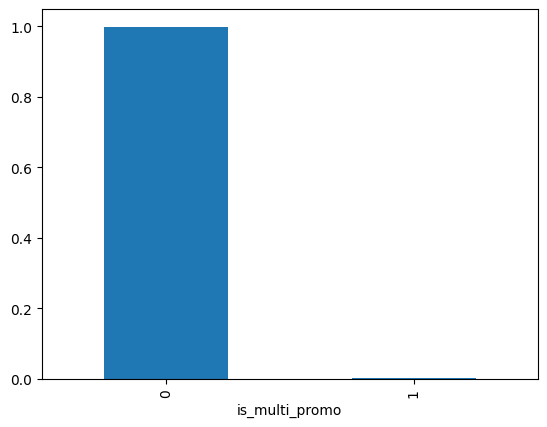

In [197]:
subset = promo_usage[promo_usage["has_promo"] == 1]

subset["is_multi_promo"].value_counts(normalize=True).plot(kind="bar")

<Axes: xlabel='num_promos_used', ylabel='count'>

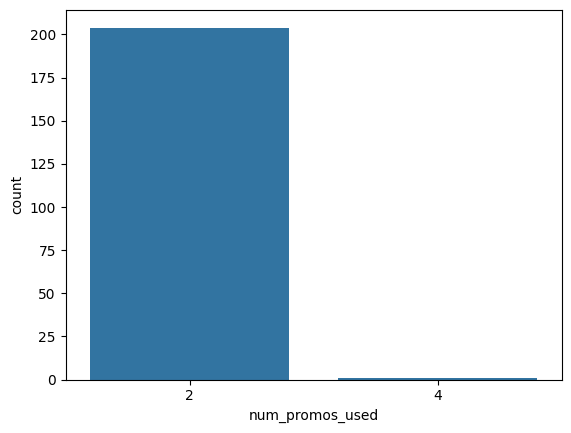

In [198]:
multi = promo_usage[promo_usage["is_multi_promo"] == 1]
sns.countplot(x="num_promos_used", data=multi)

# **7. PAYMENTS**

**1. DATA UNDERSTANDING**

In [199]:
print("- Dữ liệu:")
payments.head()

- Dữ liệu:


,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


In [200]:
# Số cột và số hàng của dữ liệu
print(f"- Số hàng dữ liệu: {payments.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {payments.shape[1]} cột.")

- Số hàng dữ liệu: 646945 dòng.
- Số cột dữ liệu: 4 cột.


In [201]:
# Thuộc tính của dữ liệu
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  object 
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 19.7+ MB


In [202]:
# Thuộc tính dạng số 
numeric_cols_payments = payments.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_payments}")

- Numeric columns: Index(['order_id', 'payment_value', 'installments'], dtype='object')


In [203]:
payments[numeric_cols_payments].corr()

,order_id,payment_value,installments
order_id,1.000000,0.105785,0.000438
payment_value,0.105785,1.000000,0.003627
installments,0.000438,0.003627,1.000000


In [204]:
# Thống kê thuộc tính dạng số
payments.describe()

,order_id,payment_value,installments
count,646945.000000,646945.000000,646945.000000
mean,417189.470332,24238.334426,3.448319
std,240785.704463,22378.475324,3.119582
min,1.000000,389.740000,1.000000
25%,208728.000000,7681.060000,1.000000
50%,417211.000000,17229.440000,3.000000
75%,625628.000000,33706.350000,6.000000
max,834397.000000,331570.400000,12.000000


In [205]:
# Thuộc tính dạng phân loại 
categorical_cols_payments = payments.select_dtypes(include=['object', 'category']).columns 
print(f"- Categorical columns: {categorical_cols_payments}")

- Categorical columns: Index(['payment_method'], dtype='object')


In [206]:
# Thống kê thuộc tính dạng phân loại 
for col in categorical_cols_payments: 
    print(f"\n- Phân bổ thuộc tính {col}: ") 
    print(payments[col].value_counts(ascending=False))


- Phân bổ thuộc tính payment_method: 
payment_method
credit_card      356352
paypal            97018
cod               96681
apple_pay         64763
bank_transfer     32131
Name: count, dtype: int64


**2. DATA CLEANING**

In [207]:
# Kiểm tra dữ liệu bị thiếu
print("- Dữ liệu bị thiếu:")
payments.isnull().sum()

- Dữ liệu bị thiếu:


order_id          0
payment_method    0
payment_value     0
installments      0
dtype: int64

In [208]:
# Kiểm tra dữ liệu trùng lặp
print(f"- Số dòng dữ liệu bị lặp: {payments.duplicated().sum()} dòng.")

- Số dòng dữ liệu bị lặp: 0 dòng.


**3. OUTLIERS**

In [209]:
# Giá trị ngoại lai của payment_value
# Q1, Q3, IQR
payment_value_Q1 = payments['payment_value'].quantile(0.25)
payment_value_Q3 = payments['payment_value'].quantile(0.75)
payment_value_IQR = payment_value_Q3 - payment_value_Q1

# Xác định ngưỡng trên, ngưỡng dưới
payment_value_lower_bound = payment_value_Q1 - 1.5 * payment_value_IQR
payment_value_upper_bound = payment_value_Q3 + 1.5 * payment_value_IQR

# Các giá trị ngoại lai
payment_value_outliers = payments[(payments['payment_value'] < payment_value_lower_bound) | (payments['payment_value'] > payment_value_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {price_IQR: .2f}")
print(f"- Ngưỡng dưới: {price_lower_bound}")
print(f"- Ngưỡng trên: {price_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(payment_value_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(payment_value_outliers)/len(payments)*100:.2f}%")

Kết quả: 
- IQR:  7661.07
- Ngưỡng dưới: -11432.158365485004
- Ngưỡng trên: 19212.117073345056
- Số lượng giá trị ngoại lai: 30219
- Tỷ lệ ngoại lai: 4.67%


In [210]:
# Giá trị ngoại lai của installments
# Q1, Q3, IQR
installments_Q1 = payments['installments'].quantile(0.25)
installments_Q3 = payments['installments'].quantile(0.75)
installments_IQR = installments_Q3 - installments_Q1

# Xác định ngưỡng trên, ngưỡng dưới
installments_lower_bound = installments_Q1 - 1.5 * installments_IQR
installments_upper_bound = installments_Q3 + 1.5 * installments_IQR

# Các giá trị ngoại lai
installments_outliers = payments[(payments['installments'] < installments_lower_bound) | (payments['installments'] > installments_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {price_IQR: .2f}")
print(f"- Ngưỡng dưới: {installments_lower_bound}")
print(f"- Ngưỡng trên: {installments_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(installments_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(installments_outliers)/len(payments)*100:.2f}%")

Kết quả: 
- IQR:  7661.07
- Ngưỡng dưới: -6.5
- Ngưỡng trên: 13.5
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


**4. FEATURE ENGINEERING**

In [211]:
# Log transform
payments['log_payment_value'] = np.log1p(payments['payment_value'])

In [212]:
# trả góp
payments['is_installment'] = (payments['installments'] > 1).astype(int)

In [213]:
# installment_bucket
payments['installment_bucket'] = pd.cut(
    payments['installments'],
    bins=[0, 1, 3, 6, 12],
    labels=['1', '2-3', '4-6', '7-12']
)

In [214]:
payments['is_long_installment'] = (
    payments['installments'] >= 7
).astype(int)

In [215]:
# Tiền trả mỗi kỳ
payments['payment_per_installment'] = (
    payments['payment_value'] / payments['installments']
)

In [216]:
# Nhóm tiền trả
payments['payment_value_qcut'] = pd.qcut(
    payments['payment_value'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

In [217]:
# giá trị ngoại lai
payments['is_high_value'] = (
    payments['payment_value'] > payment_value_upper_bound
)

# **8. SHIPMENTS**

**1. DATA UNDERSTANDING**

In [222]:
# Dữ liệu
print("- Dữ liệu: ")
shipments.head()

- Dữ liệu: 


,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79


In [223]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {shipments.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {shipments.shape[1]} cột.")

- Số dòng dữ liệu: 566067 dòng.
- Số cột dữ liệu: 4 cột.


In [224]:
# Tổng quan thuộc tính dữ liệu
shipments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       566067 non-null  int64  
 1   ship_date      566067 non-null  object 
 2   delivery_date  566067 non-null  object 
 3   shipping_fee   566067 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 17.3+ MB


In [225]:
# Thuộc tính dạng số
numeric_cols_ship = shipments.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_ship}")

- Numeric columns: Index(['order_id', 'shipping_fee'], dtype='object')


In [226]:
# Thống kê thuộc tính dạng số
shipments.describe()

,order_id,shipping_fee
count,566067.000000,566067.000000
mean,415816.869664,4.962857
std,240007.311562,8.887355
min,1.000000,0.000000
25%,208192.500000,0.870000
50%,415866.000000,1.730000
75%,623218.500000,2.600000
max,834325.000000,32.000000


In [227]:
# Thuộc tính dạng phân loại
categorical_cols_ship = shipments.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_ship}")

- Categorical columns: Index(['ship_date', 'delivery_date'], dtype='object')


In [228]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_ship:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(shipments[col].value_counts(ascending=False))


- Phân bổ thuộc tính ship_date: 
ship_date
2018-06-02    678
2017-06-03    592
2018-06-03    588
2018-06-01    579
2017-06-02    554
             ... 
2021-01-16     21
2021-01-05     21
2021-01-09     20
2022-12-29     20
2020-03-03     11
Name: count, Length: 3831, dtype: int64

- Phân bổ thuộc tính delivery_date: 
delivery_date
2018-06-06    562
2018-06-07    506
2018-06-08    484
2016-05-05    482
2016-05-04    470
             ... 
2021-01-11     23
2021-01-12     21
2021-01-16     19
2012-07-07     15
2012-07-06      6
Name: count, Length: 3831, dtype: int64


**2. DATA CLEANING**

In [229]:
# Kiểm tra giá trị thiếu
print("- Dữ liệu bị thiếu: ")
shipments.isnull().sum()

- Dữ liệu bị thiếu: 


order_id         0
ship_date        0
delivery_date    0
shipping_fee     0
dtype: int64

In [230]:
print(f"- Số dòng bị trùng lặp: {shipments.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


In [231]:
# Chuyển đổi dữ liệu thuộc tính delivery_date sang thời gian
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])

In [232]:
# Chuyển đổi dữ liệu thuộc tính ship_date sang thời gian
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])

**3. MERGE DỮ LIỆU + KIỂM TRA**

In [233]:
df = shipments.merge(orders, on="order_id", how="inner")
shipments = df

In [234]:
# Kiểm tra các dòng dữ liệu vi phạm order status
invalid_shipments = shipments[
    (~shipments['order_status'].isin(['shipped', 'delivered', 'returned'])) &
    (shipments['ship_date'].notna())
]

print(invalid_shipments.head())
print("Số dòng vi phạm:", len(invalid_shipments))

Empty DataFrame
Columns: [order_id, ship_date, delivery_date, shipping_fee, order_date, customer_id, zip, order_status, payment_method, device_type, order_source, order_year, order_month, order_quarter, order_dayofweek, order_dayofweek_name, order_is_weekend, order_year_month, week_of_year, prev_order_date, days_since_last_order, customer_total_orders, customer_order_rank, is_delivered, is_cancelled, is_returned, is_shipped, is_paid, is_created, customer_delivery_rate, customer_cancel_rate, customer_return_rate, customer_ship_rate, customer_create_rate, num_devices_used, num_sources_used, first_source, last_source, source_conversion_rate, cohort_month, cohort_index]
Index: []

[0 rows x 41 columns]
Số dòng vi phạm: 0


**4. OUTLIERS**

In [235]:
# Giá trị ngoại lai của shipping_fee
# Q1, Q3, IQR
shipping_fee_Q1 = shipments['shipping_fee'].quantile(0.25)
shipping_fee_Q3 = shipments['shipping_fee'].quantile(0.75)
shipping_fee_IQR = shipping_fee_Q3 - shipping_fee_Q1

# Xác định ngưỡng trên, ngưỡng dưới
shipping_fee_lower_bound = shipping_fee_Q1 - 1.5 * shipping_fee_IQR
shipping_fee_upper_bound = shipping_fee_Q3 + 1.5 * shipping_fee_IQR

# Các giá trị ngoại lai
shipping_fee_outliers = shipments[(shipments['shipping_fee'] < shipping_fee_lower_bound) | (shipments['shipping_fee'] > shipping_fee_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {price_IQR: .2f}")
print(f"- Ngưỡng dưới: {shipping_fee_lower_bound}")
print(f"- Ngưỡng trên: {shipping_fee_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(shipping_fee_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(shipping_fee_outliers)/len(shipments)*100:.2f}%")

Kết quả: 
- IQR:  7661.07
- Ngưỡng dưới: -1.7249999999999996
- Ngưỡng trên: 5.195
- Số lượng giá trị ngoại lai: 76050
- Tỷ lệ ngoại lai: 13.43%


**5. FEATURE ENGINEERING**

In [236]:
shipments['ship_dow'] = shipments['ship_date'].dt.dayofweek
shipments['delivery_dow'] = shipments['delivery_date'].dt.dayofweek

shipments['ship_is_weekend'] = shipments['ship_dow'].isin([5,6]).astype(int)
shipments['delivery_is_weekend'] = shipments['delivery_dow'].isin([5,6]).astype(int)

In [237]:
# Số ngày giao
shipments['delivery_duration'] = (
    shipments['delivery_date'] - shipments['ship_date']
).dt.days

In [238]:
# Tạo flag
shipments['same_day_delivery'] = (shipments['delivery_duration'] == 0).astype(int)

shipments['fast_delivery'] = (shipments['delivery_duration'] <= 2).astype(int)

shipments['late_delivery'] = (shipments['delivery_duration'] > 5).astype(int)

In [239]:
shipments['is_free_shipping'] = (shipments['shipping_fee'] == 0).astype(int)

In [240]:
shipments['shipping_fee_per_day'] = (
    shipments['shipping_fee'] / shipments['delivery_duration']
).replace([float('inf')], 0).fillna(0)

In [241]:
shipments['free_but_slow'] = (
    (shipments['shipping_fee'] == 0) & 
    (shipments['delivery_duration'] > 5)
).astype(int)

shipments['expensive_but_slow'] = (
    (shipments['shipping_fee'] > shipments['shipping_fee'].median()) & 
    (shipments['delivery_duration'] > 5)
).astype(int)

In [242]:
shipments['processing_time'] = (
    shipments['ship_date'] - pd.to_datetime(shipments['order_date'])
).dt.days

shipments['total_fulfillment_time'] = (
    shipments['delivery_date'] - pd.to_datetime(shipments['order_date'])
).dt.days

In [243]:
shipments['delivery_speed_score'] = (
    shipments['delivery_duration'] / (shipments['shipping_fee'] + 1)
)

# **9. RETURNS**

**1. DATA UNDERSTANDING**

In [256]:
# Dữ liệu
print("- Dữ liệu: ")
returns.head()

- Dữ liệu: 


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [257]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {returns.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {returns.shape[1]} cột.")

- Số dòng dữ liệu: 39939 dòng.
- Số cột dữ liệu: 7 cột.


In [258]:
# Tổng quan thuộc tính dữ liệu
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   return_id        39939 non-null  object 
 1   order_id         39939 non-null  int64  
 2   product_id       39939 non-null  int64  
 3   return_date      39939 non-null  object 
 4   return_reason    39939 non-null  object 
 5   return_quantity  39939 non-null  int64  
 6   refund_amount    39939 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 2.1+ MB


In [259]:
# Thuộc tính dạng số
numeric_cols_return = returns.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_return}")

- Numeric columns: Index(['order_id', 'product_id', 'return_quantity', 'refund_amount'], dtype='object')


In [260]:
# Thống kê thuộc tính dạng số
returns.describe()

,order_id,product_id,return_quantity,refund_amount
count,39939.000000,39939.000000,39939.000000,39939.000000
mean,409061.984176,1244.232730,2.743834,12784.458964
std,240063.904576,691.747822,1.828260,14092.150154
min,2.000000,3.000000,1.000000,458.810000
25%,202651.000000,702.000000,1.000000,3573.395000
50%,404254.000000,992.000000,2.000000,7888.880000
75%,615620.000000,2048.000000,4.000000,16881.990000
max,833351.000000,2412.000000,8.000000,160937.940000


In [261]:
# Thuộc tính dạng phân loại
categorical_cols_return = returns.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_return}")

- Categorical columns: Index(['return_id', 'return_date', 'return_reason'], dtype='object')


In [262]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_return:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(returns[col].value_counts(ascending=False))


- Phân bổ thuộc tính return_id: 
return_id
RET-051504    1
RET-000001    1
RET-000002    1
RET-051369    1
RET-051372    1
             ..
RET-000007    1
RET-000008    1
RET-000010    1
RET-000012    1
RET-000013    1
Name: count, Length: 39939, dtype: int64

- Phân bổ thuộc tính return_date: 
return_date
2016-06-18    34
2014-04-17    33
2016-04-19    33
2013-06-19    33
2018-06-15    33
              ..
2012-07-20     1
2012-07-12     1
2022-11-15     1
2012-07-11     1
2022-11-09     1
Name: count, Length: 3806, dtype: int64

- Phân bổ thuộc tính return_reason: 
return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
Name: count, dtype: int64


**2. DATA CLEANING**

In [263]:
# Kiểm tra giá trị thiếu
returns.isnull().sum()

return_id          0
order_id           0
product_id         0
return_date        0
return_reason      0
return_quantity    0
refund_amount      0
dtype: int64

In [264]:
print(f"- Số dòng bị trùng lặp: {returns.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


In [265]:
returns['return_date'] = pd.to_datetime(returns['return_date'])

**3. OUTLIERS**

In [266]:
# Giá trị ngoại lai của return_quantity
# Q1, Q3, IQR
return_quantity_Q1 = returns['return_quantity'].quantile(0.25)
return_quantity_Q3 = returns['return_quantity'].quantile(0.75)
return_quantity_IQR = return_quantity_Q3 - return_quantity_Q1

# Xác định ngưỡng trên, ngưỡng dưới
return_quantity_lower_bound = return_quantity_Q1 - 1.5 * return_quantity_IQR
return_quantity_upper_bound = return_quantity_Q3 + 1.5 * return_quantity_IQR

# Các giá trị ngoại lai
return_quantity_outliers = returns[(returns['return_quantity'] < return_quantity_lower_bound) | (returns['return_quantity'] > return_quantity_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {return_quantity_IQR: .2f}")
print(f"- Ngưỡng dưới: {return_quantity_lower_bound}")
print(f"- Ngưỡng trên: {return_quantity_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(return_quantity_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(return_quantity_outliers)/len(returns)*100:.2f}%")

Kết quả: 
- IQR:  3.00
- Ngưỡng dưới: -3.5
- Ngưỡng trên: 8.5
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


In [267]:
# Giá trị ngoại lai của return_refund
# Q1, Q3, IQR
refund_amount_Q1 = returns['refund_amount'].quantile(0.25)
refund_amount_Q3 = returns['refund_amount'].quantile(0.75)
refund_amount_IQR = refund_amount_Q3 - refund_amount_Q1

# Xác định ngưỡng trên, ngưỡng dưới
refund_amount_lower_bound = refund_amount_Q1 - 1.5 * refund_amount_IQR
refund_amount_upper_bound = refund_amount_Q3 + 1.5 * refund_amount_IQR

# Các giá trị ngoại lai
refund_amount_outliers = returns[(returns['refund_amount'] < refund_amount_lower_bound) | (returns['refund_amount'] > refund_amount_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {refund_amount_IQR: .2f}")
print(f"- Ngưỡng dưới: {refund_amount_lower_bound}")
print(f"- Ngưỡng trên: {refund_amount_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(refund_amount_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(refund_amount_outliers)/len(returns)*100:.2f}%")

Kết quả: 
- IQR:  13308.59
- Ngưỡng dưới: -16389.497499999994
- Ngưỡng trên: 36844.88249999999
- Số lượng giá trị ngoại lai: 2778
- Tỷ lệ ngoại lai: 6.96%


**4. MERGE DỮ LIỆU**

In [268]:
df = returns.merge(orders, on="order_id", how="inner")

df = df.merge(products, on="product_id", how="inner")

returns = df

In [269]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   return_id               39939 non-null  object        
 1   order_id                39939 non-null  int64         
 2   product_id              39939 non-null  int64         
 3   return_date             39939 non-null  datetime64[ns]
 4   return_reason           39939 non-null  object        
 5   return_quantity         39939 non-null  int64         
 6   refund_amount           39939 non-null  float64       
 7   order_date              39939 non-null  datetime64[ns]
 8   customer_id             39939 non-null  int64         
 9   zip                     39939 non-null  object        
 10  order_status            39939 non-null  object        
 11  payment_method          39939 non-null  object        
 12  device_type             39939 non-null  object

**5. FEATURE ENGINEERING**

In [270]:
returns["return_delay"] = (returns["return_date"] - returns["order_date"]).dt.days

In [271]:
def return_speed(x):
    if x <= 3:
        return "fast"
    elif x <= 10:
        return "medium"
    else:
        return "slow"

returns["return_speed"] = returns["return_delay"].apply(return_speed)

In [272]:
returns["price_bucket"] = pd.cut(
    returns["price"],
    bins=5,  
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

In [273]:
# Trả hàng theo:
# Size
size_return_rate = returns.groupby("size")["return_quantity"].transform("mean")
returns["size_return_rate"] = size_return_rate

# Color
color_return_rate = returns.groupby("color")["return_quantity"].transform("mean")
returns["color_return_rate"] = color_return_rate

In [274]:
returns["price_x_return_rate"] = returns["price"] * returns["customer_return_rate"]

returns["price_x_delay"] = returns["price"] * returns["return_delay"]

In [275]:
returns["is_high_return"] = (returns["return_delay"] <= 7).astype(int)
returns["is_large_return"] = (returns["return_quantity"] > 1).astype(int)

In [276]:
returns["recency_x_frequency"] = returns["days_since_last_order"] * returns["customer_total_orders"]

# **10. REVIEWS**

**1. DATA UNDERSTANDING**

In [297]:
# Dữ liệu
print("- Dữ liệu: ")
reviews.head()

- Dữ liệu: 


,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [298]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {reviews.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {reviews.shape[1]} cột.")

- Số dòng dữ liệu: 113551 dòng.
- Số cột dữ liệu: 7 cột.


In [299]:
# Tổng quan thuộc tính dữ liệu
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   review_id     113551 non-null  object
 1   order_id      113551 non-null  int64 
 2   product_id    113551 non-null  int64 
 3   customer_id   113551 non-null  int64 
 4   review_date   113551 non-null  object
 5   rating        113551 non-null  int64 
 6   review_title  113551 non-null  object
dtypes: int64(4), object(3)
memory usage: 6.1+ MB


In [300]:
# Thuộc tính dạng số
numeric_cols_reviews = reviews.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_reviews}")

- Numeric columns: Index(['order_id', 'product_id', 'customer_id', 'rating'], dtype='object')


In [301]:
# Thống kê thuộc tính dạng số
reviews.describe()

,order_id,product_id,customer_id,rating
count,113551.000000,113551.000000,113551.000000,113551.000000
mean,408999.519740,1232.018705,85694.342762,3.936011
std,239021.922809,690.839232,48501.480918,1.149867
min,1.000000,3.000000,2.000000,1.000000
25%,202048.500000,689.000000,42096.000000,3.000000
50%,406841.000000,981.000000,89755.000000,4.000000
75%,614844.000000,2045.000000,133850.000000,5.000000
max,833296.000000,2412.000000,157563.000000,5.000000


In [302]:
# Thuộc tính dạng phân loại
categorical_cols_reviews = reviews.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_reviews}")

- Categorical columns: Index(['review_id', 'review_date', 'review_title'], dtype='object')


In [303]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_reviews:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(reviews[col].value_counts(ascending=False))


- Phân bổ thuộc tính review_id: 
review_id
REV-0146984    1
REV-0000001    1
REV-0000002    1
REV-0000003    1
REV-0000005    1
              ..
REV-0000025    1
REV-0000026    1
REV-0000027    1
REV-0000028    1
REV-0000030    1
Name: count, Length: 113551, dtype: int64

- Phân bổ thuộc tính review_date: 
review_date
2017-05-06    77
2014-05-11    76
2017-06-14    76
2017-06-19    76
2016-06-07    75
              ..
2022-02-23     2
2012-07-13     2
2012-07-14     2
2012-07-12     1
2012-07-10     1
Name: count, Length: 3825, dtype: int64

- Phân bổ thuộc tính review_title: 
review_title
Very satisfied             11450
Highly recommend           11407
Great quality              11218
Excellent product!         11181
Good overall                9185
Happy with purchase         9171
Solid choice                9070
Works well                  8986
Mixed feelings              5706
Average product             5656
Decent, nothing special     5654
Some issues                 3037
Would 

**2. DATA CLEANING**

In [304]:
# Kiểm tra giá trị thiếu
reviews.isnull().sum()

review_id       0
order_id        0
product_id      0
customer_id     0
review_date     0
rating          0
review_title    0
dtype: int64

In [305]:
print(f"- Số dòng bị trùng lặp: {reviews.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


In [306]:
# Chuẩn hoá dạng dữ liệu thời gian
reviews["review_date"] = pd.to_datetime(reviews["review_date"])

**3. OUTLIERS**

In [307]:
# Giá trị ngoại lai của rating
# Q1, Q3, IQR
rating_Q1 = reviews['rating'].quantile(0.25)
rating_Q3 = reviews['rating'].quantile(0.75)
rating_IQR = rating_Q3 - rating_Q1

# Xác định ngưỡng trên, ngưỡng dưới
rating_lower_bound = rating_Q1 - 1.5 * rating_IQR
rating_upper_bound = rating_Q3 + 1.5 * rating_IQR

# Các giá trị ngoại lai
rating_outliers = reviews[(reviews['rating'] < rating_lower_bound) | (reviews['rating'] > rating_upper_bound)]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {rating_IQR: .2f}")
print(f"- Ngưỡng dưới: {rating_lower_bound}")
print(f"- Ngưỡng trên: {rating_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(rating_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(rating_outliers)/len(reviews)*100:.2f}%")

Kết quả: 
- IQR:  2.00
- Ngưỡng dưới: 0.0
- Ngưỡng trên: 8.0
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


**4. MERGE DỮ LIỆU**

In [308]:
df = reviews.merge(orders, on="order_id", how="inner")
df = df.merge(products, on='product_id', how="inner")
df = df.merge(customers, left_on='customer_id_x', right_on="customer_id")

reviews = df
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 70 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   review_id               113551 non-null  object        
 1   order_id                113551 non-null  int64         
 2   product_id              113551 non-null  int64         
 3   customer_id_x           113551 non-null  int64         
 4   review_date             113551 non-null  datetime64[ns]
 5   rating                  113551 non-null  int64         
 6   review_title            113551 non-null  object        
 7   order_date              113551 non-null  datetime64[ns]
 8   customer_id_y           113551 non-null  int64         
 9   zip_x                   113551 non-null  object        
 10  order_status            113551 non-null  object        
 11  payment_method          113551 non-null  object        
 12  device_type             113551

In [309]:
cols = [
    'review_id', 'rating', 'review_date', 'review_title',
    'product_id', 'category', 'segment', 'price', 'cogs', 'margin',
    'customer_id', 'customer_total_orders', 'customer_order_rank',
    'days_since_last_order', 'order_id', 'order_date'
]

reviews = reviews.reindex(columns=cols)

**5. FEATURE ENGINEEING**

In [310]:
reviews['days_after_purchase'] = (reviews['review_date'] - reviews['order_date']).dt.days

reviews['review_weekday'] = reviews['review_date'].dt.weekday
reviews['review_month'] = reviews['review_date'].dt.month

reviews['is_weekend_review'] = reviews['review_weekday'].isin([5, 6]).astype(int)

reviews['is_same_day_review'] = (reviews['days_after_purchase'] == 0).astype(int)

In [311]:
reviews['rating_group'] = pd.cut(
    reviews['rating'],
    bins=[0, 2, 3, 5],
    labels=['Negative', 'Neutral', 'Positive']
)

In [312]:
reviews['is_new_customer'] = (reviews['customer_total_orders'] <= 1).astype(int)

# nhóm khách hàng
reviews['customer_segment'] = pd.cut(
    reviews['customer_total_orders'],
    bins=[0, 1, 3, 10, 1000],
    labels=['New', 'Light', 'Active', 'Loyal']
)

# recency inverse
reviews['recency_score'] = 1 / (reviews['days_since_last_order'] + 1)

# churn risk (tuỳ domain chỉnh threshold)
reviews['is_churn_risk'] = (reviews['days_since_last_order'] > 60).astype(int)

In [313]:
reviews['profit_margin_ratio'] = reviews['margin'] / (reviews['price'] + 1e-6)

reviews['price_bucket'] = pd.qcut(reviews['price'], q=3, labels=['Low', 'Mid', 'High'])

In [314]:
reviews['price_performance_ratio'] = reviews['rating'] / (reviews['price'] + 1)

In [315]:
product_stats = reviews.groupby('product_id').agg(
    product_avg_rating=('rating', 'mean'),
    product_rating_std=('rating', 'std'),
    product_review_count=('rating', 'count')
).reset_index()

reviews = reviews.merge(product_stats, on='product_id', how='left')

In [316]:
category_stats = reviews.groupby('category').agg(
    category_avg_rating=('rating', 'mean')
).reset_index()

if 'category_avg_rating' in reviews.columns:
    reviews = reviews.drop(columns=['category_avg_rating'])


reviews = reviews.merge(category_stats, on='category', how='left')

In [317]:
reviews['rating_gap_vs_product'] = reviews['rating'] - reviews['product_avg_rating']
reviews['rating_gap_vs_category'] = reviews['rating'] - reviews['category_avg_rating']

In [318]:
customer_stats = reviews.groupby('customer_id').agg(
    customer_avg_rating=('rating', 'mean'),
    customer_rating_std=('rating', 'std'),
    customer_review_count=('rating', 'count')
).reset_index()

cols_to_drop = [
    'customer_avg_rating',
    'customer_rating_std',
    'customer_review_count'
]

reviews = reviews.drop(columns=cols_to_drop, errors='ignore')


reviews = reviews.merge(customer_stats, on='customer_id', how='left')

# **11. SALES**

**1. DATA UNDERSTANDING**

In [339]:
# Dữ liệu
print("- Dữ liệu: ")
sales.head()

- Dữ liệu: 


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [340]:
# Số dòng và cột dữ liệu
print(f"- Số dòng dữ liệu: {sales.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {sales.shape[1]} cột.")

- Số dòng dữ liệu: 3833 dòng.
- Số cột dữ liệu: 3 cột.


In [341]:
# Tổng quan thuộc tính dữ liệu
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB


In [342]:
# Thuộc tính dạng số
numeric_cols_sales = sales.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_sales}")

- Numeric columns: Index(['Revenue', 'COGS'], dtype='object')


In [343]:
# Thống kê thuộc tính dạng số
sales.describe()

,Revenue,COGS
count,3.833000e+03,3.833000e+03
mean,4.286584e+06,3.695134e+06
std,2.624840e+06,2.219789e+06
min,2.798139e+05,2.365763e+05
25%,2.471089e+06,2.150580e+06
50%,3.647304e+06,3.161113e+06
75%,5.350877e+06,4.637294e+06
max,2.090527e+07,1.653586e+07


In [344]:
# Thuộc tính dạng phân loại
categorical_cols_sales = sales.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_sales}")

- Categorical columns: Index(['Date'], dtype='object')


In [345]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_sales:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(sales[col].value_counts(ascending=False))


- Phân bổ thuộc tính Date: 
Date
2022-12-31    1
2012-07-04    1
2012-07-05    1
2012-07-06    1
2012-07-07    1
             ..
2012-08-01    1
2012-08-02    1
2012-08-03    1
2012-08-04    1
2012-08-05    1
Name: count, Length: 3833, dtype: int64


**2. DATA CLEANING**

In [346]:
# Kiểm tra giá trị thiếu
sales.isnull().sum()

Date       0
Revenue    0
COGS       0
dtype: int64

In [347]:
print(f"- Số dòng bị trùng lặp: {sales.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


In [348]:
sales["Date"] = pd.to_datetime(sales["Date"])

**3. OUTLIERS**

In [349]:
# Giá trị ngoại lai của Revenue
# Q1, Q3, IQR
Revenue_Q1 = sales['Revenue'].quantile(0.25)
Revenue_Q3 = sales['Revenue'].quantile(0.75)
Revenue_IQR = Revenue_Q3 - Revenue_Q1

# Xác định ngưỡng trên, ngưỡng dưới
Revenue_lower_bound = Revenue_Q1 - 1.5 * Revenue_IQR
Revenue_upper_bound = Revenue_Q3 + 1.5 * Revenue_IQR

# Các giá trị ngoại lai
Revenue_outliers = sales[
    (sales['Revenue'] < Revenue_lower_bound) | 
    (sales['Revenue'] > Revenue_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {Revenue_IQR:.2f}")
print(f"- Ngưỡng dưới: {Revenue_lower_bound}")
print(f"- Ngưỡng trên: {Revenue_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(Revenue_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(Revenue_outliers)/len(sales)*100:.2f}%")

Kết quả: 
- IQR: 2879788.38
- Ngưỡng dưới: -1848593.7500000005
- Ngưỡng trên: 9670559.77
- Số lượng giá trị ngoại lai: 169
- Tỷ lệ ngoại lai: 4.41%


In [350]:
# Giá trị ngoại lai của COGS
# Q1, Q3, IQR
COGS_Q1 = sales['COGS'].quantile(0.25)
COGS_Q3 = sales['COGS'].quantile(0.75)
COGS_IQR = COGS_Q3 - COGS_Q1

# Xác định ngưỡng trên, ngưỡng dưới
COGS_lower_bound = COGS_Q1 - 1.5 * COGS_IQR
COGS_upper_bound = COGS_Q3 + 1.5 * COGS_IQR

# Các giá trị ngoại lai
COGS_outliers = sales[
    (sales['COGS'] < COGS_lower_bound) | 
    (sales['COGS'] > COGS_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {COGS_IQR:.2f}")
print(f"- Ngưỡng dưới: {COGS_lower_bound}")
print(f"- Ngưỡng trên: {COGS_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(COGS_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(COGS_outliers)/len(sales)*100:.2f}%")

Kết quả: 
- IQR: 2486713.69
- Ngưỡng dưới: -1579490.3050000002
- Ngưỡng trên: 8367364.455
- Số lượng giá trị ngoại lai: 165
- Tỷ lệ ngoại lai: 4.30%


**4. FEATURE ENGINEERING**

In [351]:
sales['GrossProfit'] = sales['Revenue'] - sales['COGS']

sales['GrossMargin'] = sales['GrossProfit'] / sales['Revenue']
sales['COGSRatio'] = sales['COGS'] / sales['Revenue']

In [352]:
sales['Revenue_index'] = sales['Revenue'] / sales['Revenue'].iloc[0]
sales['COGS_index'] = sales['COGS'] / sales['COGS'].iloc[0]
sales['Profit_index'] = sales['GrossProfit'] / sales['GrossProfit'].iloc[0]

In [353]:
sales['COGS_share'] = sales['COGS'] / sales['Revenue']
sales['Profit_share'] = sales['GrossProfit'] / sales['Revenue']

In [354]:
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['YearMonth'] = sales['Date'].dt.to_period('M').astype(str)

sales['Quarter'] = sales['Date'].dt.to_period('Q').astype(str)
sales['DayOfWeek'] = sales['Date'].dt.day_name()

# **12. INVENTORY**

**1. DATA UNDERSTANDING**

In [365]:
print("- Dữ liệu:")
inventory.head()

- Dữ liệu:


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


In [366]:
# Số dòng và số cột dữ liệu
print(f"- Số dòng dữ liệu: {inventory.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {inventory.shape[1]} cột.")

- Số dòng dữ liệu: 60247 dòng.
- Số cột dữ liệu: 17 cột.


In [367]:
# Tổng quan thuộc tính dữ liệu
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   snapshot_date      60247 non-null  object 
 1   product_id         60247 non-null  int64  
 2   stock_on_hand      60247 non-null  int64  
 3   units_received     60247 non-null  int64  
 4   units_sold         60247 non-null  int64  
 5   stockout_days      60247 non-null  int64  
 6   days_of_supply     60247 non-null  float64
 7   fill_rate          60247 non-null  float64
 8   stockout_flag      60247 non-null  int64  
 9   overstock_flag     60247 non-null  int64  
 10  reorder_flag       60247 non-null  int64  
 11  sell_through_rate  60247 non-null  float64
 12  product_name       60247 non-null  object 
 13  category           60247 non-null  object 
 14  segment            60247 non-null  object 
 15  year               60247 non-null  int64  
 16  month              602

In [368]:
# Thuộc tính dạng số
numeric_col_inventory = inventory.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_col_inventory}")

- Numeric columns: Index(['product_id', 'stock_on_hand', 'units_received', 'units_sold',
       'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag',
       'overstock_flag', 'reorder_flag', 'sell_through_rate', 'year', 'month'],
      dtype='object')


In [369]:
# Thống kê thuộc tính dạng số
inventory.describe()

,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
std,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629
min,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000


In [370]:
# Thuộc tính dạng phân loại
categorical_cols_inventory = inventory.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_inventory}")

- Categorical columns: Index(['snapshot_date', 'product_name', 'category', 'segment'], dtype='object')


In [371]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_inventory:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(inventory[col].value_counts(ascending=False))


- Phân bổ thuộc tính snapshot_date: 
snapshot_date
2018-05-31    562
2021-03-31    551
2018-06-30    550
2018-04-30    550
2021-04-30    548
             ... 
2021-11-30    389
2022-01-31    388
2020-01-31    383
2021-01-31    377
2022-11-30    376
Name: count, Length: 126, dtype: int64

- Phân bổ thuộc tính product_name: 
product_name
VietMode RP-10       203
VietMode RP-09       203
VietMode RP-12       190
VietMode RP-11       190
VietMode RP-33       170
                    ... 
PhoenixWear UC-05      1
VietMode MA-30         1
DragonWear MA-35       1
DragonWear MA-18       1
DragonWear MA-30       1
Name: count, Length: 1465, dtype: int64

- Phân bổ thuộc tính category: 
category
Streetwear    31020
Outdoor       21050
GenZ           4674
Casual         3503
Name: count, dtype: int64

- Phân bổ thuộc tính segment: 
segment
Activewear     18290
Everyday       13598
Performance     7673
Balanced        6622
Trendy          4674
Premium         3182
Standard        3127
All-weather

**2. DATA CLEANING**

In [372]:
# Kiểm tra giá trị thiếu
inventory.isnull().sum()

snapshot_date        0
product_id           0
stock_on_hand        0
units_received       0
units_sold           0
stockout_days        0
days_of_supply       0
fill_rate            0
stockout_flag        0
overstock_flag       0
reorder_flag         0
sell_through_rate    0
product_name         0
category             0
segment              0
year                 0
month                0
dtype: int64

In [373]:
print(f"- Số dòng bị trùng lặp: {inventory.duplicated().sum()} dòng.")

- Số dòng bị trùng lặp: 0 dòng.


In [374]:
# Chuyển dữ liệu sang datetime
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])

**3. OUTLIERS**

In [375]:
# Giá trị ngoại lai của stock_on_hand
# Q1, Q3, IQR
stock_on_hand_Q1 = inventory['stock_on_hand'].quantile(0.25)
stock_on_hand_Q3 = inventory['stock_on_hand'].quantile(0.75)
stock_on_hand_IQR = stock_on_hand_Q3 - stock_on_hand_Q1

# Xác định ngưỡng trên, ngưỡng dưới
stock_on_hand_lower_bound = stock_on_hand_Q1 - 1.5 * stock_on_hand_IQR
stock_on_hand_upper_bound = stock_on_hand_Q3 + 1.5 * stock_on_hand_IQR

# Các giá trị ngoại lai
stock_on_hand_outliers = inventory[
    (inventory['stock_on_hand'] < stock_on_hand_lower_bound) |
    (inventory['stock_on_hand'] > stock_on_hand_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {stock_on_hand_IQR:.2f}")
print(f"- Ngưỡng dưới: {stock_on_hand_lower_bound}")
print(f"- Ngưỡng trên: {stock_on_hand_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(stock_on_hand_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(stock_on_hand_outliers)/len(inventory)*100:.2f}%")

Kết quả: 
- IQR: 195.00
- Ngưỡng dưới: -277.5
- Ngưỡng trên: 502.5
- Số lượng giá trị ngoại lai: 6432
- Tỷ lệ ngoại lai: 10.68%


In [376]:
# Giá trị ngoại lai của units_received (số lượng hàng đã nhập)
# Q1, Q3, IQR
units_received_Q1 = inventory['units_received'].quantile(0.25)
units_received_Q3 = inventory['units_received'].quantile(0.75)
units_received_IQR = units_received_Q3 - units_received_Q1

# Xác định ngưỡng trên, ngưỡng dưới
units_received_lower_bound = units_received_Q1 - 1.5 * units_received_IQR
units_received_upper_bound = units_received_Q3 + 1.5 * units_received_IQR

# Các giá trị ngoại lai
units_received_outliers = inventory[
    (inventory['units_received'] < units_received_lower_bound) |
    (inventory['units_received'] > units_received_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {units_received_IQR:.2f}")
print(f"- Ngưỡng dưới: {units_received_lower_bound}")
print(f"- Ngưỡng trên: {units_received_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(units_received_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(units_received_outliers)/len(inventory)*100:.2f}%")

Kết quả: 
- IQR: 17.00
- Ngưỡng dưới: -23.5
- Ngưỡng trên: 44.5
- Số lượng giá trị ngoại lai: 6392
- Tỷ lệ ngoại lai: 10.61%


In [377]:
# Giá trị ngoại lai của units_sold (số lượng hàng đã bán)
# Q1, Q3, IQR
units_sold_Q1 = inventory['units_sold'].quantile(0.25)
units_sold_Q3 = inventory['units_sold'].quantile(0.75)
units_sold_IQR = units_sold_Q3 - units_sold_Q1

# Xác định ngưỡng trên, ngưỡng dưới
units_sold_lower_bound = units_sold_Q1 - 1.5 * units_sold_IQR
units_sold_upper_bound = units_sold_Q3 + 1.5 * units_sold_IQR

# Các giá trị ngoại lai
units_sold_outliers = inventory[
    (inventory['units_sold'] < units_sold_lower_bound) |
    (inventory['units_sold'] > units_sold_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {units_sold_IQR:.2f}")
print(f"- Ngưỡng dưới: {units_sold_lower_bound}")
print(f"- Ngưỡng trên: {units_sold_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(units_sold_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(units_sold_outliers)/len(inventory)*100:.2f}%")

Kết quả: 
- IQR: 14.00
- Ngưỡng dưới: -19.0
- Ngưỡng trên: 37.0
- Số lượng giá trị ngoại lai: 6388
- Tỷ lệ ngoại lai: 10.60%


In [378]:
# Giá trị ngoại lai của stockout_days (số ngày hết hàng)
# Q1, Q3, IQR
stockout_days_Q1 = inventory['stockout_days'].quantile(0.25)
stockout_days_Q3 = inventory['stockout_days'].quantile(0.75)
stockout_days_IQR = stockout_days_Q3 - stockout_days_Q1

# Xác định ngưỡng trên, ngưỡng dưới
stockout_days_lower_bound = stockout_days_Q1 - 1.5 * stockout_days_IQR
stockout_days_upper_bound = stockout_days_Q3 + 1.5 * stockout_days_IQR

# Các giá trị ngoại lai
stockout_days_outliers = inventory[
    (inventory['stockout_days'] < stockout_days_lower_bound) |
    (inventory['stockout_days'] > stockout_days_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {stockout_days_IQR:.2f}")
print(f"- Ngưỡng dưới: {stockout_days_lower_bound}")
print(f"- Ngưỡng trên: {stockout_days_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(stockout_days_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(stockout_days_outliers)/len(inventory)*100:.2f}%")

Kết quả: 
- IQR: 2.00
- Ngưỡng dưới: -3.0
- Ngưỡng trên: 5.0
- Số lượng giá trị ngoại lai: 724
- Tỷ lệ ngoại lai: 1.20%


In [379]:
# Giá trị ngoại lai của days_of_supply (số ngày đủ hàng)
# Q1, Q3, IQR
days_of_supply_Q1 = inventory['days_of_supply'].quantile(0.25)
days_of_supply_Q3 = inventory['days_of_supply'].quantile(0.75)
days_of_supply_IQR = days_of_supply_Q3 - days_of_supply_Q1

# Xác định ngưỡng trên, ngưỡng dưới
days_of_supply_lower_bound = days_of_supply_Q1 - 1.5 * days_of_supply_IQR
days_of_supply_upper_bound = days_of_supply_Q3 + 1.5 * days_of_supply_IQR

# Các giá trị ngoại lai
days_of_supply_outliers = inventory[
    (inventory['days_of_supply'] < days_of_supply_lower_bound) |
    (inventory['days_of_supply'] > days_of_supply_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {days_of_supply_IQR:.2f}")
print(f"- Ngưỡng dưới: {days_of_supply_lower_bound}")
print(f"- Ngưỡng trên: {days_of_supply_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(days_of_supply_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(days_of_supply_outliers)/len(inventory)*100:.2f}%")

Kết quả: 
- IQR: 587.10
- Ngưỡng dưới: -784.6499999999999
- Ngưỡng trên: 1563.7499999999998
- Số lượng giá trị ngoại lai: 7455
- Tỷ lệ ngoại lai: 12.37%


In [380]:
# Giá trị ngoại lai của fill_rate (tỷ lệ đáp ứng đơn hàng)
# Q1, Q3, IQR
fill_rate_Q1 = inventory['fill_rate'].quantile(0.25)
fill_rate_Q3 = inventory['fill_rate'].quantile(0.75)
fill_rate_IQR = fill_rate_Q3 - fill_rate_Q1

# Xác định ngưỡng trên, ngưỡng dưới
fill_rate_lower_bound = fill_rate_Q1 - 1.5 * fill_rate_IQR
fill_rate_upper_bound = fill_rate_Q3 + 1.5 * fill_rate_IQR

# Các giá trị ngoại lai
fill_rate_outliers = inventory[
    (inventory['fill_rate'] < fill_rate_lower_bound) |
    (inventory['fill_rate'] > fill_rate_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {fill_rate_IQR:.2f}")
print(f"- Ngưỡng dưới: {fill_rate_lower_bound}")
print(f"- Ngưỡng trên: {fill_rate_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(fill_rate_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(fill_rate_outliers)/len(inventory)*100:.2f}%")

Kết quả: 
- IQR: 0.07
- Ngưỡng dưới: 0.83325
- Ngưỡng trên: 1.10005
- Số lượng giá trị ngoại lai: 724
- Tỷ lệ ngoại lai: 1.20%


In [381]:
# Giá trị ngoại lai của sell_through_rate (tỷ lệ bán ra)
# Q1, Q3, IQR
sell_through_rate_Q1 = inventory['sell_through_rate'].quantile(0.25)
sell_through_rate_Q3 = inventory['sell_through_rate'].quantile(0.75)
sell_through_rate_IQR = sell_through_rate_Q3 - sell_through_rate_Q1

# Xác định ngưỡng trên, ngưỡng dưới
sell_through_rate_lower_bound = sell_through_rate_Q1 - 1.5 * sell_through_rate_IQR
sell_through_rate_upper_bound = sell_through_rate_Q3 + 1.5 * sell_through_rate_IQR

# Các giá trị ngoại lai
sell_through_rate_outliers = inventory[
    (inventory['sell_through_rate'] < sell_through_rate_lower_bound) |
    (inventory['sell_through_rate'] > sell_through_rate_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {sell_through_rate_IQR:.2f}")
print(f"- Ngưỡng dưới: {sell_through_rate_lower_bound}")
print(f"- Ngưỡng trên: {sell_through_rate_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(sell_through_rate_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(sell_through_rate_outliers)/len(inventory)*100:.2f}%")

Kết quả: 
- IQR: 0.20
- Ngưỡng dưới: -0.2519
- Ngưỡng trên: 0.5321
- Số lượng giá trị ngoại lai: 1284
- Tỷ lệ ngoại lai: 2.13%


**4. FEATURE ENGINEERING**

In [382]:
# Time feature
inventory["year_month"] = inventory["snapshot_date"].dt.to_period("M").astype(str)

In [383]:
inventory["net_inventory_change"] = inventory["units_received"] - inventory["units_sold"]

inventory["inventory_turnover_rate"] = np.where(
    inventory["stock_on_hand"] > 0,
    inventory["units_sold"] / inventory["stock_on_hand"],
    np.nan
)
inventory["sell_through_rate_calc"] = np.where(
    (inventory["stock_on_hand"] + inventory["units_received"]) > 0,
    inventory["units_sold"] / (inventory["stock_on_hand"] + inventory["units_received"]),
    np.nan
)

In [384]:
inventory["critical_stock_flag"] = (inventory["days_of_supply"] < 7).astype(int)

inventory["service_level_gap"] = 1 - inventory["fill_rate"]

inventory["stockout_risk_score"] = (
    inventory["stockout_days"] * 0.4 +
    inventory["service_level_gap"] * 100 * 0.4 +
    (inventory["critical_stock_flag"] * 100) * 0.2
)

In [385]:
inventory["overstock_intensity"] = np.where(
    inventory["units_sold"] > 0,
    inventory["stock_on_hand"] / inventory["units_sold"],
    np.nan
)

In [386]:
inventory["stock_efficiency_score"] = np.where(
    (inventory["stock_on_hand"] + inventory["units_received"]) > 0,
    inventory["units_sold"] / (inventory["stock_on_hand"] + inventory["units_received"]),
        np.nan
    )

inventory["sales_velocity"] = np.where(
    inventory["stockout_days"] > 0,
    inventory["units_sold"] / inventory["stockout_days"],
    inventory["units_sold"]
)

In [387]:
inventory["reorder_urgency_score"] = (
    (inventory["reorder_flag"] * 50) +
    (inventory["critical_stock_flag"] * 30) +
    ((1 - inventory["fill_rate"]) * 20)
)

In [388]:
inventory["inventory_health_score"] = (
    inventory["fill_rate"] * 40 +
    (inventory["days_of_supply"].clip(0, 30) / 30) * 30 +
    (1 - inventory["stockout_flag"]) * 20 +

    (1 - inventory["overstock_flag"]) * 10
)

# **13. WEB TRAFFIC**

**1. DATA UNDERSTANDING**

In [401]:
print("- Dữ liệu:")
web_traffic.head()

- Dữ liệu:


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


In [402]:
# Số dòng và số cột dữ liệu
print(f"- Số dòng dữ liệu: {web_traffic.shape[0]} dòng.")
print(f"- Số cột dữ liệu: {web_traffic.shape[1]} cột.")

- Số dòng dữ liệu: 3652 dòng.
- Số cột dữ liệu: 7 cột.


In [403]:
# Tổng quan thuộc tính dữ liệu
web_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      3652 non-null   object 
 1   sessions                  3652 non-null   int64  
 2   unique_visitors           3652 non-null   int64  
 3   page_views                3652 non-null   int64  
 4   bounce_rate               3652 non-null   float64
 5   avg_session_duration_sec  3652 non-null   float64
 6   traffic_source            3652 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 199.8+ KB


In [404]:
# Thuộc tính dạng số
numeric_cols_web_traffic = web_traffic.select_dtypes(include=['number']).columns
print(f"- Numeric columns: {numeric_cols_web_traffic}")

- Numeric columns: Index(['sessions', 'unique_visitors', 'page_views', 'bounce_rate',
       'avg_session_duration_sec'],
      dtype='object')


In [405]:
# Thống kê thuộc tính dạng số
web_traffic.describe()

,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
count,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,25041.768072,19031.404436,108615.224535,0.004487,210.283242
std,9422.609335,7237.953062,44472.055524,0.000753,63.771711
min,7973.000000,6136.000000,30451.000000,0.003200,100.100000
25%,17099.250000,12915.000000,72982.000000,0.003848,156.700000
50%,23633.500000,17924.000000,101010.500000,0.004450,209.200000
75%,31782.750000,24191.750000,138086.000000,0.005160,266.200000
max,50947.000000,40430.000000,275560.000000,0.005800,319.900000


In [406]:
# Thuộc tính dạng phân loại
categorical_cols_web_traffic = web_traffic.select_dtypes(include=['object', 'category']).columns
print(f"- Categorical columns: {categorical_cols_web_traffic}")

- Categorical columns: Index(['date', 'traffic_source'], dtype='object')


In [407]:
# Thống kê thuộc tính dạng phân loại
for col in categorical_cols_web_traffic:
    print(f"\n- Phân bổ thuộc tính {col}: ")
    print(web_traffic[col].value_counts(ascending=False))


- Phân bổ thuộc tính date: 
date
2022-12-31    1
2013-01-01    1
2013-01-02    1
2013-01-03    1
2022-11-22    1
             ..
2013-01-08    1
2013-01-09    1
2013-01-10    1
2013-01-11    1
2013-01-12    1
Name: count, Length: 3652, dtype: int64

- Phân bổ thuộc tính traffic_source: 
traffic_source
organic_search    1090
paid_search        784
social_media       632
email_campaign     505
referral           375
direct             266
Name: count, dtype: int64


**2. DATA CLEANING**

In [408]:
web_traffic.isnull().sum()

date                        0
sessions                    0
unique_visitors             0
page_views                  0
bounce_rate                 0
avg_session_duration_sec    0
traffic_source              0
dtype: int64

In [409]:
print(f"- Số dòng dữ liệu bị trùng: {web_traffic.duplicated().sum()} dòng.")

- Số dòng dữ liệu bị trùng: 0 dòng.


In [410]:
# Chuyển dữ liệu sang datetime
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

**3. OUTLIERS**

In [411]:
# Giá trị ngoại lai của sessions
# Q1, Q3, IQR
sessions_Q1 = web_traffic['sessions'].quantile(0.25)
sessions_Q3 = web_traffic['sessions'].quantile(0.75)
sessions_IQR = sessions_Q3 - sessions_Q1

# Xác định ngưỡng trên, ngưỡng dưới
sessions_lower_bound = sessions_Q1 - 1.5 * sessions_IQR
sessions_upper_bound = sessions_Q3 + 1.5 * sessions_IQR

# Các giá trị ngoại lai
sessions_outliers = web_traffic[
    (web_traffic['sessions'] < sessions_lower_bound) | 
    (web_traffic['sessions'] > sessions_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {sessions_IQR: .2f}")
print(f"- Ngưỡng dưới: {sessions_lower_bound}")
print(f"- Ngưỡng trên: {sessions_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(sessions_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(sessions_outliers)/len(web_traffic)*100:.2f}%")

Kết quả: 
- IQR:  14683.50
- Ngưỡng dưới: -4926.0
- Ngưỡng trên: 53808.0
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


In [412]:
# Giá trị ngoại lai của page_views
# Q1, Q3, IQR
pv_Q1 = web_traffic['page_views'].quantile(0.25)
pv_Q3 = web_traffic['page_views'].quantile(0.75)
pv_IQR = pv_Q3 - pv_Q1

# Xác định ngưỡng trên, ngưỡng dưới
pv_lower_bound = pv_Q1 - 1.5 * pv_IQR
pv_upper_bound = pv_Q3 + 1.5 * pv_IQR

# Các giá trị ngoại lai
pv_outliers = web_traffic[
    (web_traffic['page_views'] < pv_lower_bound) | 
    (web_traffic['page_views'] > pv_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {pv_IQR: .2f}")
print(f"- Ngưỡng dưới: {pv_lower_bound}")
print(f"- Ngưỡng trên: {pv_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(pv_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(pv_outliers)/len(web_traffic)*100:.2f}%")

Kết quả: 
- IQR:  65104.00
- Ngưỡng dưới: -24674.0
- Ngưỡng trên: 235742.0
- Số lượng giá trị ngoại lai: 18
- Tỷ lệ ngoại lai: 0.49%


In [413]:
# Giá trị ngoại lai của unique_visitors
# Q1, Q3, IQR
uv_Q1 = web_traffic['unique_visitors'].quantile(0.25)
uv_Q3 = web_traffic['unique_visitors'].quantile(0.75)
uv_IQR = uv_Q3 - uv_Q1

# Xác định ngưỡng trên, ngưỡng dưới
uv_lower_bound = uv_Q1 - 1.5 * uv_IQR
uv_upper_bound = uv_Q3 + 1.5 * uv_IQR

# Các giá trị ngoại lai
uv_outliers = web_traffic[
    (web_traffic['unique_visitors'] < uv_lower_bound) | 
    (web_traffic['unique_visitors'] > uv_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {uv_IQR: .2f}")
print(f"- Ngưỡng dưới: {uv_lower_bound}")
print(f"- Ngưỡng trên: {uv_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(uv_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(uv_outliers)/len(web_traffic)*100:.2f}%")

Kết quả: 
- IQR:  11276.75
- Ngưỡng dưới: -4000.125
- Ngưỡng trên: 41106.875
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


In [414]:
# Giá trị ngoại lai của bounce_rate
# Q1, Q3, IQR
br_Q1 = web_traffic['bounce_rate'].quantile(0.25)
br_Q3 = web_traffic['bounce_rate'].quantile(0.75)
br_IQR = br_Q3 - br_Q1

# Xác định ngưỡng trên, ngưỡng dưới
br_lower_bound = br_Q1 - 1.5 * br_IQR
br_upper_bound = br_Q3 + 1.5 * br_IQR

# Các giá trị ngoại lai
br_outliers = web_traffic[
    (web_traffic['bounce_rate'] < br_lower_bound) | 
    (web_traffic['bounce_rate'] > br_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {br_IQR: .2f}")
print(f"- Ngưỡng dưới: {br_lower_bound}")
print(f"- Ngưỡng trên: {br_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(br_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(br_outliers)/len(web_traffic)*100:.2f}%")

Kết quả: 
- IQR:  0.00
- Ngưỡng dưới: 0.001878750000000001
- Ngưỡng trên: 0.007128749999999999
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


In [415]:
# Giá trị ngoại lai của avg_session_duration_sec
# Q1, Q3, IQR
asd_Q1 = web_traffic['avg_session_duration_sec'].quantile(0.25)
asd_Q3 = web_traffic['avg_session_duration_sec'].quantile(0.75)
asd_IQR = asd_Q3 - asd_Q1

# Xác định ngưỡng trên, ngưỡng dưới
asd_lower_bound = asd_Q1 - 1.5 * asd_IQR
asd_upper_bound = asd_Q3 + 1.5 * asd_IQR

# Các giá trị ngoại lai
asd_outliers = web_traffic[
    (web_traffic['avg_session_duration_sec'] < asd_lower_bound) | 
    (web_traffic['avg_session_duration_sec'] > asd_upper_bound)
]

# Kết quả
print("Kết quả: ")
print(f"- IQR: {asd_IQR: .2f}")
print(f"- Ngưỡng dưới: {asd_lower_bound}")
print(f"- Ngưỡng trên: {asd_upper_bound}")
print(f"- Số lượng giá trị ngoại lai: {len(asd_outliers)}")
print(f"- Tỷ lệ ngoại lai: {len(asd_outliers)/len(web_traffic)*100:.2f}%")

Kết quả: 
- IQR:  109.50
- Ngưỡng dưới: -7.550000000000011
- Ngưỡng trên: 430.45
- Số lượng giá trị ngoại lai: 0
- Tỷ lệ ngoại lai: 0.00%


**4. FEATURE ENGINEERING**

In [416]:
# Time series
web_traffic['year'] = web_traffic['date'].dt.year
web_traffic['month'] = web_traffic['date'].dt.month
web_traffic['day'] = web_traffic['date'].dt.day
web_traffic['day_of_week'] = web_traffic['date'].dt.day_name()
web_traffic['week'] = web_traffic['date'].dt.isocalendar().week
web_traffic['is_weekend'] = web_traffic['day_of_week'].isin(['Saturday', 'Sunday'])

In [417]:
web_traffic['pages_per_session'] = web_traffic['page_views'] / web_traffic['sessions']
web_traffic['sessions_per_user'] = web_traffic['sessions'] / web_traffic['unique_visitors']
web_traffic['avg_time_per_page'] = web_traffic['avg_session_duration_sec'] / web_traffic['page_views']

In [418]:
web_traffic['bounce_rate_level'] = pd.cut(
    web_traffic['bounce_rate'],
    bins=[0, 0.4, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)

In [419]:
web_traffic['sessions_7d'] = web_traffic['sessions'].rolling(7).mean()

In [420]:
web_traffic['z_sessions'] = (web_traffic['sessions'] - web_traffic['sessions'].mean()) / web_traffic['sessions'].std()

In [434]:
products.to_csv("/kaggle/working/products_updated.csv", index=False)
customers.to_csv("/kaggle/working/customers_updated.csv", index=False)
promotions.to_csv("/kaggle/working/promotions_updated.csv", index=False)
geography.to_csv("/kaggle/working/geography_updated.csv", index=False)
orders.to_csv("/kaggle/working/orders_updated.csv", index=False)
order_items.to_csv("/kaggle/working/order_items_updated.csv", index=False)
payments.to_csv("/kaggle/working/payments_updated.csv", index=False)
shipments.to_csv("/kaggle/working/shipments_updated.csv", index=False)
returns.to_csv("/kaggle/working/returns_updated.csv", index=False)
reviews.to_csv("/kaggle/working/reviews_updated.csv", index=False)
sales.to_csv("/kaggle/working/sales_updated.csv", index=False)
inventory.to_csv("/kaggle/working/inventory_updated.csv", index=False)
web_traffic.to_csv("/kaggle/working/web_traffic_updated.csv", index=False)